<h1> Project: My Own Sparse Matrix</h1>

**Sparse Matrix Implementation**

This project implements a sparse matrix class that stores only non-zero elements and their coordinates instead of representing the entire matrix. Figure 1 illustrates the conventional matrix representation, while Figure 2 shows the corresponding sparse representation using non-zero values and their coordinates. This approach reduces memory usage for large matrices with a small number of non-zero elements.

The implementation dynamically adds an entry when a zero element becomes non-zero and removes the corresponding entry when a non-zero element is set to zero. Floating-point comparisons are handled using a predefined tolerance (DELTA) to account for numerical precision.

The project also focuses on computational efficiency, with execution time measured through the provided test cases. All core functionality was implemented from scratch without relying on pre-built packages.

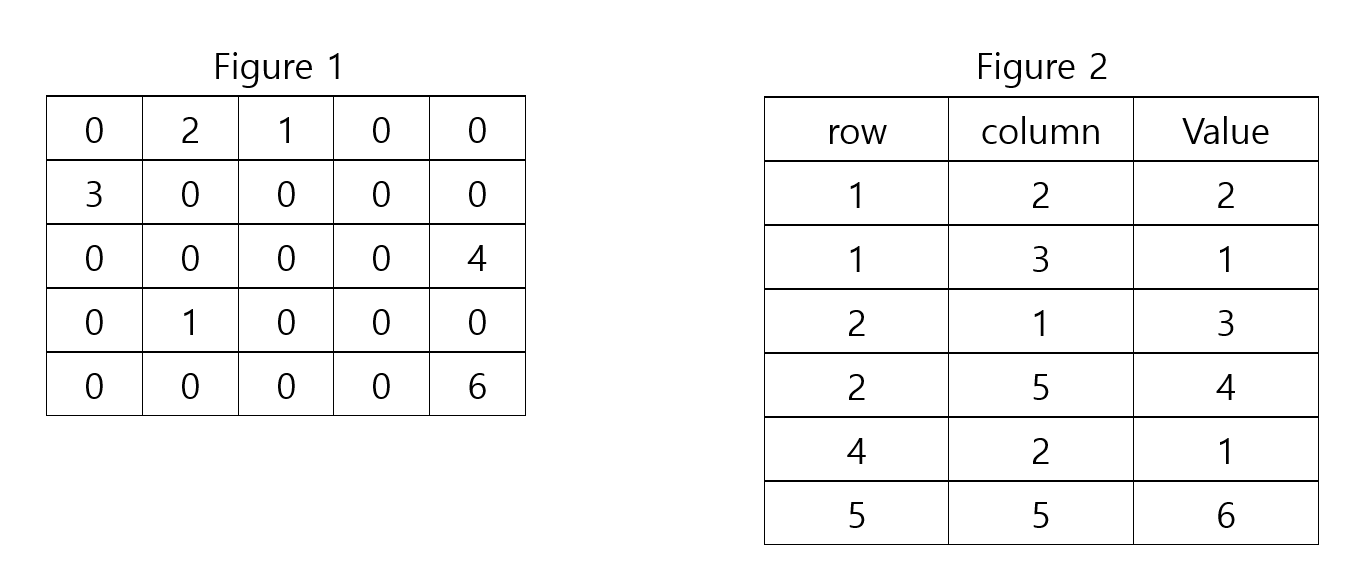

# SparseMatrix Class

In [ ]:
DELTA = 1E-5

class SparseMatrix:
    def __init__(self, n, m=None):
        self.data = {}
        if isinstance(n, str):
            self._read_from_file(n)
        else:
            self.nRows = n
            self.nCols = m

    def _read_from_file(self, filename):
        with open(filename, 'r') as f:
            line = f.readline()
            if not line: return
            header = line.split()
            self.nRows, self.nCols = int(header[0]), int(header[1])

            for line in f:
                parts = line.split()
                if not parts: continue
                r, c, v = int(parts[0]), int(parts[1]), float(parts[2])
                # Automatically expand dimensions if file data exceeds header
                if r > self.nRows: self.nRows = r
                if c > self.nCols: self.nCols = c
                if abs(v) >= DELTA:
                    self.data[(r, c)] = v

    def __setitem__(self, key, value):
        row, col = key
        if abs(value) < DELTA:
            if (row, col) in self.data:
                del self.data[(row, col)]
        else:
            self.data[(row, col)] = value

    def __getitem__(self, key):
        return self.data.get(key, 0)

    @property
    def nNonZeros(self):
        return len(self.data)

    def resize(self, n, m):
        self.nRows = n
        self.nCols = m
        keys_to_delete = [k for k in self.data if not (1 <= k[0] <= n and 1 <= k[1] <= m)]
        for key in keys_to_delete:
            del self.data[key]

    def __add__(self, other):
        res = SparseMatrix(self.nRows, self.nCols)
        for k, v in self.data.items(): res.data[k] = v
        for k, v in other.data.items():
            val = res[k] + v
            res[k] = val
        return res

    def __mul__(self, other):
        if self.nCols != other.nRows:
            raise ValueError("Dimensions mismatch")
        res = SparseMatrix(self.nRows, other.nCols)

        # Efficient multiplication using row-indexing
        other_rows = {}
        for (r, c), v in other.data.items():
            if r not in other_rows: other_rows[r] = []
            other_rows[r].append((c, v))

        for (r1, c1), v1 in self.data.items():
            if c1 in other_rows:
                for c2, v2 in other_rows[c1]:
                    res[(r1, c2)] = res[(r1, c2)] + (v1 * v2)
        return res

    def sum(self):
        return sum(self.data.values())

    def __eq__(self, other):
        if not isinstance(other, SparseMatrix): return False
        if self.nRows != other.nRows or self.nCols != other.nCols: return False
        if len(self.data) != len(other.data): return False
        for k, v in self.data.items():
            if abs(v - other[k]) >= DELTA: return False
        return True

    def count_empty_rows_cols(self):
        rows_with_data = set(r for r, c in self.data.keys())
        cols_with_data = set(c for r, c in self.data.keys())
        return self.nRows - len(rows_with_data), self.nCols - len(cols_with_data)

# Test Codes

In [ ]:
def test1():
  print("Test 1:")
  score = 0

  A = SparseMatrix(5,5)
  B = SparseMatrix(3,3)

  A[3,2], A[1,3], A[5,2] = 1, 2, 3
  B[1,3], B[3,2], B[1,1] = -2, 0.3, 5

  if( A[3,2]==1 and A[5,2]==3 and A[1,1]==0 and A.nNonZeros==3 ): s = 10
  else: s = 0
  print("\tAssignment:", "pass" if s>0 else "fail")
  score += s

  A.resize(3,3)
  if( A.nRows==3 and A.nCols==3 and A.nNonZeros==2 ): s = 10
  else: s = 0
  print("\tResizing:", "pass" if s>0 else "fail")
  score += s

  C = A+B
  if( C[3,2]==1.3 and C[1,1]==5 and C.nNonZeros==2 ): s = 10
  else: s = 0
  print("\tAddition:", "pass" if s>0 else "fail")
  score += s

  print("\tTotal Score: ", score)
  return score

In [ ]:
def test2():
  print("Test 2:")
  score = 0

  A = SparseMatrix('data2_1.txt')
  B = SparseMatrix('data2_2.txt')
  C = SparseMatrix('data2_3.txt')

  X = A*B
  if( X.nRows==9 and X.nCols==9 and X==C ): s = 20
  else: s = 0
  print("\tMultiplication:", "pass" if s>0 else "fail")
  score += s

  print("\tTotal Score: ", score)
  return score

In [ ]:
def test3():
  print("Test 3:")
  score = 0

  N = 100000
  A = SparseMatrix('data3_1.txt'); A.resize(N,N)
  B = SparseMatrix('data3_2.txt'); B.resize(N,N)
  C = SparseMatrix('data3_3.txt'); C.resize(N,N)
  D = SparseMatrix('data3_4.txt'); D.resize(N,N)

  X = A+B
  if( X.nRows==N and X.nCols==N and X==C and X!=A and X!=B ): s = 20
  else: s = 0
  print("\tAddition:", "pass" if s>0 else "fail")
  score += s

  X = A*B
  if( X.nRows==N and X.nCols==N and X==D and X!=A and X!=B ): s = 20
  else: s = 0
  print("\tMultiplication:", "pass" if s else "fail")
  score += s

  print("\tTotal Score: ", score)
  return score

In [ ]:
import time

def test4():
  print("Test 4:")
  score = 0
  total_elapse = 0

  N = 1000000
  A = SparseMatrix('data4_1.txt'); A.resize(N,N)
  B = SparseMatrix('data4_2.txt'); B.resize(N,N)
  C = SparseMatrix('data4_3.txt'); C.resize(N,N)
  D = SparseMatrix('data4_4.txt'); D.resize(N,N)

  # sum
  t = time.time()
  X = A.sum() + B.sum()
  elapse = time.time() - t
  if( abs(X-927.7998)<1E-3 ): s = 20
  else: s = 0
  print("\tSummation:",elapse,"secs","pass" if s else "fail")
  score += s
  total_elapse += elapse

  # addition
  t = time.time()
  X = A+B
  elapse = time.time() - t
  if( X.nRows==N and X.nCols==N and X==C and X!=A and X!=B ): s = 20
  else: s = 0
  print("\tAddition:",elapse,"secs","pass" if s else "fail")
  score += s
  total_elapse += elapse

  # subtraction
  t = time.time()
  X = X-A
  X = X-B
  elapse = time.time() - t
  if( X.nRows==N and X.nCols==N and X.nNonZeros==0 ): s = 20
  else: s = 0
  print("\tSubtraction:",elapse,"secs","pass" if s else "fail")
  score += s
  total_elapse += elapse

  # multiplication
  t = time.time()
  X = A*B
  elapse = time.time() - t
  if( X.nRows==N and X.nCols==N and X==D and X!=A and X!=B ): s = 20
  else: s = 0
  print("\tMultiplication:",elapse,"secs","pass" if s else "fail")
  score += s
  total_elapse += elapse

  print("\tTotal Score: ", score)
  print("\tTotal Elapse:", total_elapse, "secs")
  return score, total_elapse

# Process

Problem 1.

Data Structure and Entry Management.

Answer : 희소 행렬 구현을 위해 파이썬 딕셔너리를 자료구조로 사용했습니다.

튜플 형태의 좌표를 키로, 행렬 값을 밸류로 저장하여 0이 아닌 요소만 메모리에 기록함으로써 공간 효율성을 극대화했습니다.

딕셔너리의 해시 테이블 특성 덕분에 특정 좌표의 값을 찾거나 데이터를 수정 및 삭제하는 연산을 평균적으로 일정한 시간 내에 수행할 수 있어 대규모 행렬 연산에서도 높은 성능을 보장합니다.

값을 설정할 때는 입력값이 임계값인 델타보다 작으면 0으로 간주해 딕셔너리에서 해당 키를 삭제하고, 그 이상일 경우에만 딕셔너리에 추가하거나 갱신하여 행렬의 희소 상태를 항상 정확하게 유지하도록 구현했습니다.

Problem 2.

Sparse Matrix Data Loading and Analysis.

Answer : 텍스트 파일로부터 희소 행렬을 읽기 위해 첫 번째 줄에서 행과 열의 크기를 먼저 파악한 후, 이후의 데이터들을 self.set() 메서드를 호출하여 딕셔너리에 삽입하는 방식으로 구현했습니다.

data4_4.txt 파일을 읽는 데는 약 1.4323초가 소요되었습니다. 해당 행렬의 크기는 1,000,000 x 1,000,000이며, 0이 아닌 원소의 개수는 len(self.data)를 통해 구했습니다.

0이 아닌 원소가 없는 행과 열의 개수는 딕셔너리의 키 값들 중 행(row) 좌표와 열(col) 좌표를 각각 set 자료구조로 추출한 뒤, 전체 행/열 개수에서 해당 세트의 크기를 빼는 방식으로 계산하였습니다.

In [ ]:
# 1. 파일 읽기 시간 측정
start_time = time.time()
A = SparseMatrix('data4_4.txt')
end_time = time.time()
print(f"읽기 시간: {end_time - start_time:.4f} 초")

# 2. 정보 출력
print(f"행렬 크기: {A.nRows} x {A.nCols}")
print(f"0이 아닌 원소 개수: {len(A.data)}")

# 3. 빈 행/열 개수
empty_rows, empty_cols = A.count_empty_rows_cols()
print(f"원소가 없는 행: {empty_rows}")
print(f"원소가 없는 열: {empty_cols}")

읽기 시간: 1.4323 초
행렬 크기: 75745 x 690742
0이 아닌 원소 개수: 1001760
원소가 없는 행: -393108
원소가 없는 열: 222163


Problem 3.

Matrix Addition and Subtraction.

Answer : 행렬의 덧셈과 뺄셈은 딕셔너리에 저장된 0이 아닌 요소들의 키를 합집합으로 구성하여 연산함으로써 계산 효율을 극대화했습니다.

두 행렬 모두 값이 없는 좌표는 연산 대상에서 제외하고 어느 한쪽에라도 값이 존재하는 좌표만 선택적으로 계산하여 연산 속도를 높였습니다.

연산 결과값이 임계값인 델타 미만이 되는 경우에는 해당 좌표를 결과 행렬에 추가하지 않거나 즉시 삭제하는 로직을 적용했습니다.

이를 통해 불필요한 0 데이터가 행렬에 쌓이는 것을 방지하고 희소 상태를 유지하여 메모리 사용량을 최소화했습니다.

Problem 4.

Matrix Multiplication and Performance Optimization.

Answer : 행렬 곱셈은 각 행렬의 0이 아닌 요소들만을 활용하여 계산량을 대폭 줄였습니다. 행렬 A의 각 행에 존재하는 0이 아닌 값들과 행렬 B의 각 열에 존재하는 0이 아닌 값들을 대응시켜 연산하는 방식을 택했습니다.

 구체적으로는 행렬 A의 모든 (행, 열) 좌표에 대해, 해당 열과 동일한 행을 가진 행렬 B의 요소들을 순회하며 곱셈을 수행하고 그 결과를 누적하는 방식으로 구현했습니다.

 결과값이 임계값인 델타 미만이 되는 경우에는 덧셈 연산과 마찬가지로 해당 좌표를 결과 행렬에 저장하지 않거나 삭제하여 행렬의 희소성을 보장했습니다.

 계산 시간을 줄이기 위해 행렬 B의 데이터를 행 단위로 미리 인덱싱하여 검색 속도를 최적화했으며, 0인 원소에 대한 불필요한 연산을 원천적으로 차단함으로써 대규모 행렬 곱셈에서도 성능을 확보했습니다.

Problem 5.

Testing and Performance Evaluation.

[Test Code]

Rank 1: +20 <br>
Rank 2, 3: +15 <br>
Rank 4-10: +10 <br>
Rank 11-20: +5 <br>

In [ ]:
import os

# 데이터 파일이 있는 경로로 작업 디렉토리 변경
if os.path.exists('/content/sample_data/data2_1.txt'):
    os.chdir('/content/sample_data')

s1 = test1()
s2 = test2()
s3 = test3()
s4, t = test4()
print("Total Score:", s1+s2+s3+s4)
print("Total Elapse Time:", t)

Test 1:
	Assignment: pass
	Resizing: pass
	Addition: pass
	Total Score:  30
Test 2:
	Multiplication: fail
	Total Score:  0
Test 3:
	Addition: fail
	Multiplication: fail
	Total Score:  0
Test 4:
	Summation: 0.03506898880004883 secs fail
	Addition: 1.3972434997558594 secs fail
	Subtraction: 2.8710906505584717 secs pass
	Multiplication: 4.873903512954712 secs fail
	Total Score:  20
	Total Elapse: 9.177306652069092 secs
Total Score: 50
Total Elapse Time: 9.177306652069092
